# Recovery Inventory

Build an inventory of missing samples starting from `backfill_failures.jsonl`, parse the sample type from `source_dir_name`, and join against the old and new Hugging Face datasets.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
from datasets import load_dataset, load_dataset_builder

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 240)

FAILURES_PATH = Path("/Users/eitanturok/good-vibrations/backfill_failures.jsonl")
OLD_REPO_ID = "eturok-weizmann/vibrations"
NEW_REPO_ID = "eturok-weizmann/laser-vibrations"

In [2]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))
    return pd.DataFrame(rows)


def extract_id_column(df: pd.DataFrame) -> str | None:
    for col in ["sample_id", "sample_idx"]:
        if col in df.columns:
            return col
    return None


def repo_feature_names(repo_id: str) -> list[str]:
    builder = load_dataset_builder(repo_id)
    return list(builder.info.features.keys())


def load_repo_df(repo_id: str, columns: list[str]) -> pd.DataFrame:
    available = repo_feature_names(repo_id)
    selected = [c for c in columns if c in available]
    print(f"{repo_id}: available columns={available}")
    print(f"{repo_id}: selected columns={selected}")
    try:
        ds = load_dataset(
            repo_id,
            split="train",
            columns=selected,
            verification_mode="no_checks",
        )
    except ValueError as e:
        if "doesn't have a 'columns' key" not in str(e):
            raise
        print(f"{repo_id}: columns=... unsupported, loading full metadata then subsetting")
        ds = load_dataset(
            repo_id,
            split="train",
            verification_mode="no_checks",
        )
    df = ds.to_pandas()
    keep = [c for c in selected if c in df.columns]
    return df[keep].copy() if keep else df.copy()


def parse_source_dir_name(source_dir_name: str) -> dict:
    name = str(source_dir_name)
    lower = name.lower()

    xy_match = re.search(r"(?P<x>\d{1,2})x(?P<y>\d{1,2})y", lower)
    x_position = int(xy_match.group("x")) if xy_match else None
    y_position = int(xy_match.group("y")) if xy_match else None

    spk_match = re.search(r"_(?P<speakers>[01]{4})--", name)
    speakers = spk_match.group("speakers") if spk_match else None

    timestamp_match = re.search(r"--(?P<timestamp>\d{2}-\d{2}-\d{2}-\d{2}-\d{2})$", name)
    source_timestamp = timestamp_match.group("timestamp") if timestamp_match else None

    prefix = re.sub(r"_[01]{4}--.*$", "", name)
    prefix = re.sub(r"--.*$", "", prefix)

    is_empty = lower.startswith("empty")
    is_offgrid = "offrid" in lower or "offgrid" in lower
    is_rotated = "rotated" in lower
    is_multi_object = any(token in lower for token in ["two-", "four-", "stacked", "together", "apart", "zigzag", "cube-l"])

    if is_empty:
        sample_type = "empty"
        n_objects = 0
    elif "four-" in lower:
        sample_type = "multi_object_four"
        n_objects = 4
    elif "two-" in lower or "stacked" in lower or "together" in lower or "apart" in lower:
        sample_type = "multi_object_two"
        n_objects = 2
    elif is_offgrid and is_rotated:
        sample_type = "offgrid_rotated"
        n_objects = 1
    elif is_offgrid:
        sample_type = "offgrid"
        n_objects = 1
    elif "cube-l" in lower or lower.startswith("cube-l_"):
        sample_type = "shape_l"
        n_objects = 1
    elif "zigzag" in lower:
        sample_type = "zigzag"
        n_objects = 1
    elif x_position is not None and y_position is not None:
        sample_type = "grid_single"
        n_objects = 1
    else:
        sample_type = "unknown"
        n_objects = None

    object_name = "empty" if is_empty else "cube"

    return {
        "source_dir_name": source_dir_name,
        "source_prefix": prefix,
        "source_timestamp": source_timestamp,
        "object": object_name,
        "sample_type": sample_type,
        "n_objects_parsed": n_objects,
        "is_empty": is_empty,
        "is_offgrid": is_offgrid,
        "is_rotated": is_rotated,
        "is_multi_object": is_multi_object,
        "speakers_parsed": speakers,
        "x_position_parsed": x_position,
        "y_position_parsed": y_position,
    }


def classify_failure(error: str) -> str:
    error = str(error)
    if "experiment_config.json not found" in error:
        return "missing_experiment_config"
    if "The app is stopped or disabled" in error:
        return "modal_disabled"
    if "Request has expired" in error or "failed with status 403" in error:
        return "expired_upload_url"
    if "returned non-zero exit status 255" in error:
        return "ssh_or_remote_failure"
    if "returned non-zero exit status 1" in error:
        return "script_failure"
    return "other"


In [3]:
failures_df = load_jsonl(FAILURES_PATH)
failures_df["failure_kind"] = failures_df["error"].map(classify_failure)
parsed_df = pd.DataFrame([parse_source_dir_name(x) for x in failures_df["source_dir_name"]])
inventory_df = failures_df.merge(parsed_df, on="source_dir_name", how="left")
inventory_df = inventory_df.sort_values("sample_id").drop_duplicates(subset=["sample_id"], keep="last")

display(inventory_df.head(20))
print(f"n_failed_rows={len(failures_df)}")
print(f"n_unique_failed_sample_ids={inventory_df.index.nunique()}")


,source_dir_name,sample_id,error,traceback,timestamp,failure_kind,source_prefix,source_timestamp,object,sample_type,n_objects_parsed,is_empty,is_offgrid,is_rotated,is_multi_object,speakers_parsed,x_position_parsed,y_position_parsed
0,cube-00x07y_0100--31-03-19-03-14,27,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x07y_0100--31-03-19-03-14/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979257,missing_experiment_config,cube-00x07y,31-03-19-03-14,cube,grid_single,1,False,False,False,False,0100,0.0,7.0
1,cube-00x07y_1000--31-03-19-03-12,28,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x07y_1000--31-03-19-03-12/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979687,missing_experiment_config,cube-00x07y,31-03-19-03-12,cube,grid_single,1,False,False,False,False,1000,0.0,7.0
2,cube-00x08y_0001--31-03-19-09-21,29,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x08y_0001--31-03-19-09-21/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979759,missing_experiment_config,cube-00x08y,31-03-19-09-21,cube,grid_single,1,False,False,False,False,0001,0.0,8.0
3,cube-00x08y_0010--31-03-19-09-18,30,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x08y_0010--31-03-19-09-18/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979818,missing_experiment_config,cube-00x08y,31-03-19-09-18,cube,grid_single,1,False,False,False,False,0010,0.0,8.0
4,cube-00x08y_0100--31-03-19-09-16,31,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x08y_0100--31-03-19-09-16/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979868,missing_experiment_config,cube-00x08y,31-03-19-09-16,cube,grid_single,1,False,False,False,False,0100,0.0,8.0
5,cube-00x08y_1000--31-03-19-09-13,32,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x08y_1000--31-03-19-09-13/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979920,missing_experiment_config,cube-00x08y,31-03-19-09-13,cube,grid_single,1,False,False,False,False,1000,0.0,8.0
6,cube-00x09y_0001--31-03-19-15-45,33,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x09y_0001--31-03-19-15-45/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.979965,missing_experiment_config,cube-00x09y,31-03-19-15-45,cube,grid_single,1,False,False,False,False,0001,0.0,9.0
7,cube-00x09y_0010--31-03-19-15-43,34,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x09y_0010--31-03-19-15-43/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.980075,missing_experiment_config,cube-00x09y,31-03-19-15-43,cube,grid_single,1,False,False,False,False,0010,0.0,9.0
8,cube-00x09y_0100--31-03-19-15-41,35,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x09y_0100--31-03-19-15-41/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.980266,missing_experiment_config,cube-00x09y,31-03-19-15-41,cube,grid_single,1,False,False,False,False,0100,0.0,9.0
9,cube-00x09y_1000--31-03-19-15-39,36,/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-00x09y_1000--31-03-19-15-39/experiment_config.json not found,NoneType: None\n,2026-04-23T05:08:46.980339,missing_experiment_config,cube-00x09y,31-03-19-15-39,cube,grid_single,1,False,False,False,False,1000,0.0,9.0


n_failed_rows=201
n_unique_failed_sample_ids=201


In [4]:
old_columns = [
    "sample_idx",
    "object",
    "n_objects",
    "speakers",
    "x_position",
    "y_position",
    "raw_image",
    "cropped_image",
    "overlay_image",
    "experiment_config",
]
new_columns = [
    "sample_id",
    "experiment_id",
    "object",
    "n_objects",
    "speakers",
    "x_position",
    "y_position",
    "mask_file_name",
    "segmented_overhead_file_name",
    "speckle_vibrations_file_name",
    "audio_file_name",
    "speckle_shifts_ifft_audio_file_name",
]

old_df = load_repo_df(OLD_REPO_ID, old_columns)
new_df = load_repo_df(NEW_REPO_ID, new_columns)

old_id_col = extract_id_column(old_df)
new_id_col = extract_id_column(new_df)

print("old id col:", old_id_col)
print("new id col:", new_id_col)
print("old rows:", len(old_df))
print("new rows:", len(new_df))


eturok-weizmann/vibrations: available columns=['object', 'n_objects', 'speakers', 'box_material', 'x_position', 'y_position', 'raw_image', 'cropped_image', 'overlay_image', 'fps', 'sample_idx', 'experiment_config', 'mask_area']
eturok-weizmann/vibrations: selected columns=['sample_idx', 'object', 'n_objects', 'speakers', 'x_position', 'y_position', 'raw_image', 'cropped_image', 'overlay_image', 'experiment_config']
eturok-weizmann/laser-vibrations: available columns=['sample_id', 'segmented_overhead_file_name', 'speckle_vibrations_file_name', 'speckle_shifts_ifft_audio_file_name', 'audio_file_name', 'experiment_id', 'speakers', 'x_position', 'y_position', 'x_com', 'y_com', 'object', 'n_objects', 'box_material', 'mask_file_name', 'experiment_dir', 'manifest']
eturok-weizmann/laser-vibrations: selected columns=['sample_id', 'experiment_id', 'object', 'n_objects', 'speakers', 'x_position', 'y_position', 'mask_file_name', 'segmented_overhead_file_name', 'speckle_vibrations_file_name', 'aud

In [5]:
if old_id_col == "sample_idx":
    old_df = old_df.rename(columns={"sample_idx": "old_sample_idx"})

old_df = old_df.rename(columns={
    "object": "old_object",
    "n_objects": "old_n_objects",
    "speakers": "old_speakers",
    "x_position": "old_x_position",
    "y_position": "old_y_position",
})

new_df = new_df.rename(columns={
    "object": "new_object",
    "n_objects": "new_n_objects",
    "speakers": "new_speakers",
    "x_position": "new_x_position",
    "y_position": "new_y_position",
})

if "experiment_id" in new_df.columns:
    new_df["experiment_id"] = new_df["experiment_id"].astype(str)

if "old_sample_idx" in old_df.columns:
    old_df["old_sample_idx"] = pd.to_numeric(old_df["old_sample_idx"], errors="coerce")

if "sample_id" in new_df.columns:
    new_df["sample_id"] = pd.to_numeric(new_df["sample_id"], errors="coerce")


In [6]:
# Join by new dataset sample_id first
inventory_df = inventory_df.merge(
    new_df[[
        "sample_id",
        "experiment_id",
        "new_object",
        "new_n_objects",
        "new_speakers",
        "new_x_position",
        "new_y_position",
        "mask_file_name",
        "segmented_overhead_file_name",
        "speckle_vibrations_file_name",
        "audio_file_name",
        "speckle_shifts_ifft_audio_file_name",
    ]],
    on="sample_id",
    how="left",
)

# Join old dataset by matching source_dir_name to experiment_id if present there, otherwise leave for manual matching later
if "experiment_id" in old_df.columns:
    old_match_df = old_df.rename(columns={"experiment_id": "source_dir_name"})
else:
    old_match_df = old_df.copy()

old_keep_cols = [c for c in [
    "source_dir_name",
    "old_sample_idx",
    "old_object",
    "old_n_objects",
    "old_speakers",
    "old_x_position",
    "old_y_position",
    "segmented_overhead",
    "cropped_image",
] if c in old_match_df.columns]

if "source_dir_name" in old_match_df.columns and old_keep_cols:
    inventory_df = inventory_df.merge(old_match_df[old_keep_cols], on="source_dir_name", how="left")
else:
    inventory_df["old_sample_idx"] = pd.NA
    inventory_df["old_object"] = pd.NA
    inventory_df["old_n_objects"] = pd.NA
    inventory_df["old_speakers"] = pd.NA
    inventory_df["old_x_position"] = pd.NA
    inventory_df["old_y_position"] = pd.NA
    inventory_df["raw_image"] = pd.NA
    inventory_df["cropped_image"] = pd.NA
    inventory_df["overlay_image"] = pd.NA

inventory_df = inventory_df.sort_values("sample_id").reset_index(drop=True)


In [7]:
inventory_df["already_in_new_dataset"] = inventory_df["experiment_id"].notna()
inventory_df["old_row_found"] = inventory_df.get("old_sample_idx", pd.Series(index=inventory_df.index, dtype=float)).notna()
inventory_df["old_image_found"] = (
    inventory_df.get("raw_image", pd.Series(index=inventory_df.index, dtype=object)).notna()
    | inventory_df.get("cropped_image", pd.Series(index=inventory_df.index, dtype=object)).notna()
    | inventory_df.get("overlay_image", pd.Series(index=inventory_df.index, dtype=object)).notna()
)
inventory_df["has_new_mask"] = inventory_df["mask_file_name"].notna() if "mask_file_name" in inventory_df.columns else False
inventory_df["has_new_segmented_overhead"] = inventory_df["segmented_overhead_file_name"].notna() if "segmented_overhead_file_name" in inventory_df.columns else False
inventory_df["has_new_preview_video"] = inventory_df["speckle_vibrations_file_name"].notna() if "speckle_vibrations_file_name" in inventory_df.columns else False
inventory_df["has_new_ifft_audio"] = inventory_df["speckle_shifts_ifft_audio_file_name"].notna() if "speckle_shifts_ifft_audio_file_name" in inventory_df.columns else False

# Placeholders until we inspect old repo file layout more directly
inventory_df["old_npz_found"] = inventory_df["old_row_found"]
inventory_df["old_raw_found"] = False
inventory_df["old_preview_video_found"] = False

inventory_df["can_recover_without_raw"] = inventory_df["old_row_found"] | inventory_df["old_image_found"]
inventory_df["can_recover_full"] = inventory_df["old_raw_found"]

inventory_df["needs_manual_review"] = (
    inventory_df["sample_type"].eq("unknown")
    | inventory_df["n_objects_parsed"].isna()
    | inventory_df["speakers_parsed"].isna()
)

key_cols = [
    "sample_id",
    "source_dir_name",
    "failure_kind",
    "object",
    "sample_type",
    "n_objects_parsed",
    "is_empty",
    "is_offgrid",
    "is_multi_object",
    "speakers_parsed",
    "x_position_parsed",
    "y_position_parsed",
    "old_sample_idx",
    "old_row_found",
    "old_npz_found",
    "old_image_found",
    "old_raw_found",
    "already_in_new_dataset",
    "has_new_mask",
    "has_new_segmented_overhead",
    "has_new_preview_video",
    "has_new_ifft_audio",
    "can_recover_without_raw",
    "can_recover_full",
    "needs_manual_review",
]

display(inventory_df[key_cols].head(50))


,sample_id,source_dir_name,failure_kind,object,sample_type,n_objects_parsed,is_empty,is_offgrid,is_multi_object,speakers_parsed,x_position_parsed,y_position_parsed,old_sample_idx,old_row_found,old_npz_found,old_image_found,old_raw_found,already_in_new_dataset,has_new_mask,has_new_segmented_overhead,has_new_preview_video,has_new_ifft_audio,can_recover_without_raw,can_recover_full,needs_manual_review
0,27,cube-00x07y_0100--31-03-19-03-14,missing_experiment_config,cube,grid_single,1,False,False,False,0100,0.0,7.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
1,28,cube-00x07y_1000--31-03-19-03-12,missing_experiment_config,cube,grid_single,1,False,False,False,1000,0.0,7.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
2,29,cube-00x08y_0001--31-03-19-09-21,missing_experiment_config,cube,grid_single,1,False,False,False,0001,0.0,8.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
3,30,cube-00x08y_0010--31-03-19-09-18,missing_experiment_config,cube,grid_single,1,False,False,False,0010,0.0,8.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
4,31,cube-00x08y_0100--31-03-19-09-16,missing_experiment_config,cube,grid_single,1,False,False,False,0100,0.0,8.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
5,32,cube-00x08y_1000--31-03-19-09-13,missing_experiment_config,cube,grid_single,1,False,False,False,1000,0.0,8.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
6,33,cube-00x09y_0001--31-03-19-15-45,missing_experiment_config,cube,grid_single,1,False,False,False,0001,0.0,9.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
7,34,cube-00x09y_0010--31-03-19-15-43,missing_experiment_config,cube,grid_single,1,False,False,False,0010,0.0,9.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
8,35,cube-00x09y_0100--31-03-19-15-41,missing_experiment_config,cube,grid_single,1,False,False,False,0100,0.0,9.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False
9,36,cube-00x09y_1000--31-03-19-15-39,missing_experiment_config,cube,grid_single,1,False,False,False,1000,0.0,9.0,<NA>,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
summary_df = pd.DataFrame([
    {"metric": "n_unique_failed_sample_ids", "value": inventory_df["sample_id"].nunique()},
    {"metric": "n_already_in_new_dataset", "value": int(inventory_df["already_in_new_dataset"].sum())},
    {"metric": "n_old_row_found", "value": int(inventory_df["old_row_found"].sum())},
    {"metric": "n_old_image_found", "value": int(inventory_df["old_image_found"].sum())},
    {"metric": "n_can_recover_without_raw", "value": int(inventory_df["can_recover_without_raw"].sum())},
    {"metric": "n_can_recover_full", "value": int(inventory_df["can_recover_full"].sum())},
    {"metric": "n_needs_manual_review", "value": int(inventory_df["needs_manual_review"].sum())},
])

by_type_df = (
    inventory_df.groupby(["sample_type", "failure_kind"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["sample_type", "failure_kind"])
    .reset_index(drop=True)
)

display(summary_df)
display(by_type_df)


,metric,value
0,n_unique_failed_sample_ids,201
1,n_already_in_new_dataset,46
2,n_old_row_found,0
3,n_old_image_found,0
4,n_can_recover_without_raw,0
5,n_can_recover_full,0
6,n_needs_manual_review,0


,sample_type,failure_kind,count
0,empty,ssh_or_remote_failure,4
1,grid_single,expired_upload_url,1
2,grid_single,missing_experiment_config,61
3,grid_single,modal_disabled,40
4,grid_single,script_failure,2
5,grid_single,ssh_or_remote_failure,18
6,multi_object_four,ssh_or_remote_failure,12
7,multi_object_two,ssh_or_remote_failure,28
8,offgrid,ssh_or_remote_failure,12
9,offgrid_rotated,ssh_or_remote_failure,12


In [9]:
inventory_df.to_csv("/Users/eitanturok/good-vibrations/recovery_inventory_from_failures.csv", index=False)
print("wrote /Users/eitanturok/good-vibrations/recovery_inventory_from_failures.csv")


wrote /Users/eitanturok/good-vibrations/recovery_inventory_from_failures.csv


## Stronger Recovery Diagnostics

The old `vibrations` dataset does not expose `experiment_id`, so the direct join above is too pessimistic. These cells estimate recovery by treating failure `sample_id` as a provisional match to old `sample_idx` / `data/sample_<id>.npz`, which is how the historical helper scripts address the old repo.

In [10]:
from huggingface_hub import HfApi, hf_hub_download
import numpy as np

api = HfApi()
old_repo_files = set(api.list_repo_files(OLD_REPO_ID, repo_type="dataset"))
old_sample_idx_set = set(pd.to_numeric(old_df['old_sample_idx'], errors='coerce').dropna().astype(int).tolist()) if 'old_sample_idx' in old_df.columns else set()

inventory_df['old_row_found_by_sample_id'] = inventory_df['sample_id'].isin(old_sample_idx_set)
inventory_df['old_npz_path'] = inventory_df['sample_id'].map(lambda x: f"data/sample_{int(x):06d}.npz")
inventory_df['old_npz_found_by_path'] = inventory_df['old_npz_path'].isin(old_repo_files)
inventory_df['old_probably_recoverable_from_vibrations'] = inventory_df['old_row_found_by_sample_id'] | inventory_df['old_npz_found_by_path']

display(pd.DataFrame([
    {'metric': 'n_old_repo_rows', 'value': len(old_df)},
    {'metric': 'n_old_unique_sample_idx', 'value': len(old_sample_idx_set)},
    {'metric': 'n_failed_sample_ids_present_in_old_by_id', 'value': int(inventory_df['old_row_found_by_sample_id'].sum())},
    {'metric': 'n_failed_sample_npz_present_in_old', 'value': int(inventory_df['old_npz_found_by_path'].sum())},
    {'metric': 'n_failed_samples_probably_recoverable_from_old', 'value': int(inventory_df['old_probably_recoverable_from_vibrations'].sum())},
]))


,metric,value
0,n_old_repo_rows,547
1,n_old_unique_sample_idx,547
2,n_failed_sample_ids_present_in_old_by_id,132
3,n_failed_sample_npz_present_in_old,132
4,n_failed_samples_probably_recoverable_from_old,132


In [11]:
probe_sample_id = int(inventory_df['sample_id'].iloc[0])
probe_path = hf_hub_download(
    repo_id=OLD_REPO_ID,
    repo_type="dataset",
    filename=f"data/sample_{probe_sample_id:06d}.npz",
)
probe_npz = np.load(probe_path, allow_pickle=True)
probe_df = pd.DataFrame([
    {
        'sample_id': probe_sample_id,
        'key': key,
        'shape': tuple(probe_npz[key].shape),
        'dtype': str(probe_npz[key].dtype),
    }
    for key in probe_npz.files
])
print(f"Inspected old NPZ for sample_id={probe_sample_id}: {probe_path}")
display(probe_df)


Inspected old NPZ for sample_id=27: /Users/eitanturok/.cache/huggingface/hub/datasets--eturok-weizmann--vibrations/snapshots/ab477949cec66dc69e84b4cf3e54e57e3e13a0cc/data/sample_000027.npz


,sample_id,key,shape,dtype
0,27,shifts,"(100, 9000, 2)",float32
1,27,mask,"(956, 1069)",bool


In [12]:
recovery_by_type_df = (
    inventory_df.groupby(['sample_type'], dropna=False)
    .agg(
        n_failed=('sample_id', 'size'),
        n_already_in_new=('already_in_new_dataset', 'sum'),
        n_old_by_id=('old_row_found_by_sample_id', 'sum'),
        n_old_npz=('old_npz_found_by_path', 'sum'),
        n_probably_recoverable=('old_probably_recoverable_from_vibrations', 'sum'),
    )
    .reset_index()
    .sort_values('n_failed', ascending=False)
    .reset_index(drop=True)
)

display(recovery_by_type_df)


,sample_type,n_failed,n_already_in_new,n_old_by_id,n_old_npz,n_probably_recoverable
0,grid_single,122,41,122,122,122
1,multi_object_two,28,0,0,0,0
2,multi_object_four,12,0,2,2,2
3,offgrid,12,0,0,0,0
4,offgrid_rotated,12,0,0,0,0
5,shape_l,8,0,8,8,8
6,empty,4,4,0,0,0
7,zigzag,4,1,0,0,0


In [13]:
recovery_gap_df = inventory_df.loc[
    (~inventory_df['already_in_new_dataset']) & inventory_df['old_probably_recoverable_from_vibrations'],
    [
        'sample_id',
        'source_dir_name',
        'sample_type',
        'n_objects_parsed',
        'speakers_parsed',
        'x_position_parsed',
        'y_position_parsed',
        'failure_kind',
        'old_row_found_by_sample_id',
        'old_npz_found_by_path',
    ],
].sort_values(['sample_type', 'sample_id']).reset_index(drop=True)

print('Missing from laser-vibrations but likely recoverable from vibrations:')
display(recovery_gap_df.head(200))


Missing from laser-vibrations but likely recoverable from vibrations:


,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,old_row_found_by_sample_id,old_npz_found_by_path
0,27,cube-00x07y_0100--31-03-19-03-14,grid_single,1,0100,0.0,7.0,missing_experiment_config,True,True
1,28,cube-00x07y_1000--31-03-19-03-12,grid_single,1,1000,0.0,7.0,missing_experiment_config,True,True
2,29,cube-00x08y_0001--31-03-19-09-21,grid_single,1,0001,0.0,8.0,missing_experiment_config,True,True
3,30,cube-00x08y_0010--31-03-19-09-18,grid_single,1,0010,0.0,8.0,missing_experiment_config,True,True
4,31,cube-00x08y_0100--31-03-19-09-16,grid_single,1,0100,0.0,8.0,missing_experiment_config,True,True
...,...,...,...,...,...,...,...,...,...,...
86,540,cube-L-01_1000--31-03-21-18-01,shape_l,1,1000,NaN,NaN,ssh_or_remote_failure,True,True
87,541,cube-L_0001--31-03-21-17-19,shape_l,1,0001,NaN,NaN,ssh_or_remote_failure,True,True
88,542,cube-L_0010--31-03-21-17-17,shape_l,1,0010,NaN,NaN,ssh_or_remote_failure,True,True
89,543,cube-L_0100--31-03-21-17-15,shape_l,1,0100,NaN,NaN,ssh_or_remote_failure,True,True


In [14]:
unknown_df = inventory_df.loc[inventory_df['sample_type'] == 'unknown', ['sample_id', 'source_dir_name', 'failure_kind']].sort_values('sample_id')
print('Unknown source-dir patterns that need parser cleanup:')
display(unknown_df)


Unknown source-dir patterns that need parser cleanup:


,sample_id,source_dir_name,failure_kind


## ID Set-Difference Sanity Check

Explicitly compare failed sample IDs present in `vibrations` against the sample IDs missing from `laser-vibrations`.

In [15]:
failed_ids = set(pd.to_numeric(inventory_df['sample_id'], errors='coerce').dropna().astype(int))
old_ids = set(pd.to_numeric(old_df['old_sample_idx'], errors='coerce').dropna().astype(int)) if 'old_sample_idx' in old_df.columns else set()
new_ids = set(pd.to_numeric(new_df['sample_id'], errors='coerce').dropna().astype(int)) if 'sample_id' in new_df.columns else set()
missing_new_ids = set(range(1, max(new_ids) + 1)) - new_ids if new_ids else set()
failed_old_ids = failed_ids & old_ids
intersection_ids = failed_old_ids & missing_new_ids
failed_old_not_missing_new = sorted(failed_old_ids - missing_new_ids)
missing_new_not_failed_old = sorted(missing_new_ids - failed_old_ids)

id_sanity_df = pd.DataFrame([
    {'metric': 'n_failed_ids', 'value': len(failed_ids)},
    {'metric': 'n_failed_ids_present_in_vibrations', 'value': len(failed_old_ids)},
    {'metric': 'n_missing_ids_in_laser_vibrations_range', 'value': len(missing_new_ids)},
    {'metric': 'n_safe_recovery_ids_intersection', 'value': len(intersection_ids)},
    {'metric': 'n_in_vibrations_but_already_in_laser_vibrations', 'value': len(failed_old_not_missing_new)},
    {'metric': 'n_missing_in_laser_vibrations_but_not_found_in_vibrations_by_id', 'value': len(missing_new_not_failed_old)},
])

display(id_sanity_df)
print('failed_old_ids - missing_new_ids =')
print(failed_old_not_missing_new)
print()
print('missing_new_ids - failed_old_ids =')
print(missing_new_not_failed_old)


,metric,value
0,n_failed_ids,201
1,n_failed_ids_present_in_vibrations,131
2,n_missing_ids_in_laser_vibrations_range,156
3,n_safe_recovery_ids_intersection,91
4,n_in_vibrations_but_already_in_laser_vibrations,40
5,n_missing_in_laser_vibrations_but_not_found_in_vibrations_by_id,65


failed_old_ids - missing_new_ids =
[479, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519]

missing_new_ids - failed_old_ids =
[547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 581, 582, 583, 584, 585, 586, 587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611]


In [16]:
subset_cols = [
    'sample_id',
    'source_dir_name',
    'sample_type',
    'n_objects_parsed',
    'speakers_parsed',
    'x_position_parsed',
    'y_position_parsed',
    'failure_kind',
    'already_in_new_dataset',
    'old_row_found_by_sample_id',
    'old_npz_found_by_path',
]

failed_ids_df = inventory_df[inventory_df['sample_id'].isin(sorted(failed_ids))][subset_cols].sort_values('sample_id').reset_index(drop=True)
failed_old_ids_df = inventory_df[inventory_df['sample_id'].isin(sorted(failed_old_ids))][subset_cols].sort_values('sample_id').reset_index(drop=True)
missing_new_ids_df = inventory_df[inventory_df['sample_id'].isin(sorted(missing_new_ids))][subset_cols].sort_values('sample_id').reset_index(drop=True)
intersection_ids_df = inventory_df[inventory_df['sample_id'].isin(sorted(intersection_ids))][subset_cols].sort_values('sample_id').reset_index(drop=True)
failed_old_not_missing_new_df = inventory_df[inventory_df['sample_id'].isin(failed_old_not_missing_new)][subset_cols].sort_values('sample_id').reset_index(drop=True)
missing_new_not_failed_old_df = inventory_df[inventory_df['sample_id'].isin(missing_new_not_failed_old)][subset_cols].sort_values('sample_id').reset_index(drop=True)

print('failed_ids_df')
display(failed_ids_df)
print('failed_old_ids_df')
display(failed_old_ids_df)
print('missing_new_ids_df')
display(missing_new_ids_df)
print('intersection_ids_df')
display(intersection_ids_df)
print('failed_old_not_missing_new_df')
display(failed_old_not_missing_new_df)
print('missing_new_not_failed_old_df')
display(missing_new_not_failed_old_df)


failed_ids_df


,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path
0,27,cube-00x07y_0100--31-03-19-03-14,grid_single,1,0100,0.0,7.0,missing_experiment_config,False,True,True
1,28,cube-00x07y_1000--31-03-19-03-12,grid_single,1,1000,0.0,7.0,missing_experiment_config,False,True,True
2,29,cube-00x08y_0001--31-03-19-09-21,grid_single,1,0001,0.0,8.0,missing_experiment_config,False,True,True
3,30,cube-00x08y_0010--31-03-19-09-18,grid_single,1,0010,0.0,8.0,missing_experiment_config,False,True,True
4,31,cube-00x08y_0100--31-03-19-09-16,grid_single,1,0100,0.0,8.0,missing_experiment_config,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
197,612,cube-zigzag_1000--31-03-21-21-22,zigzag,1,1000,NaN,NaN,ssh_or_remote_failure,True,False,False
198,613,empty_0001--31-03-18-14-17,empty,0,0001,NaN,NaN,ssh_or_remote_failure,True,False,False
199,614,empty_0010--31-03-18-14-15,empty,0,0010,NaN,NaN,ssh_or_remote_failure,True,False,False
200,615,empty_0100--31-03-18-14-13,empty,0,0100,NaN,NaN,ssh_or_remote_failure,True,False,False


failed_old_ids_df


,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path
0,27,cube-00x07y_0100--31-03-19-03-14,grid_single,1,0100,0.0,7.0,missing_experiment_config,False,True,True
1,28,cube-00x07y_1000--31-03-19-03-12,grid_single,1,1000,0.0,7.0,missing_experiment_config,False,True,True
2,29,cube-00x08y_0001--31-03-19-09-21,grid_single,1,0001,0.0,8.0,missing_experiment_config,False,True,True
3,30,cube-00x08y_0010--31-03-19-09-18,grid_single,1,0010,0.0,8.0,missing_experiment_config,False,True,True
4,31,cube-00x08y_0100--31-03-19-09-16,grid_single,1,0100,0.0,8.0,missing_experiment_config,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
127,542,cube-L_0010--31-03-21-17-17,shape_l,1,0010,NaN,NaN,ssh_or_remote_failure,False,True,True
128,543,cube-L_0100--31-03-21-17-15,shape_l,1,0100,NaN,NaN,ssh_or_remote_failure,False,True,True
129,544,cube-L_1000--31-03-21-17-13,shape_l,1,1000,NaN,NaN,ssh_or_remote_failure,False,True,True
130,545,cube-four-together-00_0001--31-03-21-11-23,multi_object_four,4,0001,NaN,NaN,ssh_or_remote_failure,False,True,True


missing_new_ids_df


...

,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path
0,27,cube-00x07y_0100--31-03-19-03-14,grid_single,1,0100,0.0,7.0,missing_experiment_config,False,True,True
1,28,cube-00x07y_1000--31-03-19-03-12,grid_single,1,1000,0.0,7.0,missing_experiment_config,False,True,True
2,29,cube-00x08y_0001--31-03-19-09-21,grid_single,1,0001,0.0,8.0,missing_experiment_config,False,True,True
3,30,cube-00x08y_0010--31-03-19-09-18,grid_single,1,0010,0.0,8.0,missing_experiment_config,False,True,True
4,31,cube-00x08y_0100--31-03-19-09-16,grid_single,1,0100,0.0,8.0,missing_experiment_config,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
86,542,cube-L_0010--31-03-21-17-17,shape_l,1,0010,NaN,NaN,ssh_or_remote_failure,False,True,True
87,543,cube-L_0100--31-03-21-17-15,shape_l,1,0100,NaN,NaN,ssh_or_remote_failure,False,True,True
88,544,cube-L_1000--31-03-21-17-13,shape_l,1,1000,NaN,NaN,ssh_or_remote_failure,False,True,True
89,545,cube-four-together-00_0001--31-03-21-11-23,multi_object_four,4,0001,NaN,NaN,ssh_or_remote_failure,False,True,True


failed_old_not_missing_new_df


,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path
0,479,cube-10x07y_0100--31-03-19-08-39,grid_single,1,0100,10.0,7.0,ssh_or_remote_failure,True,True,True
1,481,cube-10x08y_0001--31-03-19-15-12,grid_single,1,0001,10.0,8.0,modal_disabled,True,True,True
2,481,cube-10x08y_0001--31-03-19-15-12,grid_single,1,0001,10.0,8.0,modal_disabled,True,True,True
3,482,cube-10x08y_0010--31-03-19-15-10,grid_single,1,0010,10.0,8.0,modal_disabled,True,True,True
4,483,cube-10x08y_0100--31-03-19-15-08,grid_single,1,0100,10.0,8.0,modal_disabled,True,True,True
5,484,cube-10x08y_1000--31-03-19-15-06,grid_single,1,1000,10.0,8.0,modal_disabled,True,True,True
6,485,cube-10x09y_0001--31-03-19-59-28,grid_single,1,0001,10.0,9.0,modal_disabled,True,True,True
7,486,cube-10x09y_0010--31-03-19-59-26,grid_single,1,0010,10.0,9.0,modal_disabled,True,True,True
8,487,cube-10x09y_0100--31-03-19-59-24,grid_single,1,0100,10.0,9.0,modal_disabled,True,True,True
9,488,cube-10x09y_1000--31-03-19-59-22,grid_single,1,1000,10.0,9.0,modal_disabled,True,True,True


missing_new_not_failed_old_df


,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path
0,547,cube-four-together-00_0100--31-03-21-11-19,multi_object_four,4,0100,NaN,NaN,ssh_or_remote_failure,False,False,False
1,548,cube-four-together-00_1000--31-03-21-11-17,multi_object_four,4,1000,NaN,NaN,ssh_or_remote_failure,False,False,False
2,549,cube-four-together-diagonal-00_0001--31-03-21-12-47,multi_object_four,4,0001,NaN,NaN,ssh_or_remote_failure,False,False,False
3,550,cube-four-together-diagonal-00_0010--31-03-21-12-45,multi_object_four,4,0010,NaN,NaN,ssh_or_remote_failure,False,False,False
4,551,cube-four-together-diagonal-00_0100--31-03-21-12-44,multi_object_four,4,0100,NaN,NaN,ssh_or_remote_failure,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
60,607,cube-two-together-vertical05x03y_0100--31-03-21-04-44,multi_object_two,2,0100,5.0,3.0,ssh_or_remote_failure,False,False,False
61,608,cube-two-together-vertical05x03y_1000--31-03-21-04-42,multi_object_two,2,1000,5.0,3.0,ssh_or_remote_failure,False,False,False
62,609,cube-zigzag_0001--31-03-21-21-28,zigzag,1,0001,NaN,NaN,ssh_or_remote_failure,False,False,False
63,610,cube-zigzag_0010--31-03-21-21-26,zigzag,1,0010,NaN,NaN,ssh_or_remote_failure,False,False,False


In [17]:
GRID_X_SIZE = 11
GRID_Y_SIZE = 12
RECOVERY_INVENTORY_CSV = Path('/Users/eitanturok/good-vibrations/recovery_inventory_from_failures.csv')

if 'inventory_df' not in globals():
    inventory_df = pd.read_csv(RECOVERY_INVENTORY_CSV)

in_new_col = 'already_in_new_dataset' if 'already_in_new_dataset' in inventory_df.columns else 'already_in_new'
old_by_id_col = 'old_row_found_by_sample_id' if 'old_row_found_by_sample_id' in inventory_df.columns else 'old_row_found'

inventory_df[in_new_col] = inventory_df[in_new_col].fillna(False).astype(bool)
inventory_df[old_by_id_col] = inventory_df[old_by_id_col].fillna(False).astype(bool)

safe_recovery_id_set = set(pd.to_numeric(inventory_df.loc[inventory_df[old_by_id_col] & ~inventory_df[in_new_col], 'sample_id'], errors='coerce').dropna().astype(int))
missing_in_new_id_set = set(pd.to_numeric(inventory_df.loc[~inventory_df[in_new_col], 'sample_id'], errors='coerce').dropna().astype(int))
missing_not_in_old_by_id_set = set(pd.to_numeric(inventory_df.loc[~inventory_df[in_new_col] & ~inventory_df[old_by_id_col], 'sample_id'], errors='coerce').dropna().astype(int))

expected_grid_speakers = sorted(
    str(s)
    for s in inventory_df['speakers_parsed'].dropna().unique()
    if re.fullmatch(r'[01]{4}', str(s)) and str(s).count('1') == 1
)

def sample_family(row: pd.Series) -> str:
    x = row.get('x_position_parsed')
    y = row.get('y_position_parsed')
    in_grid = pd.notna(x) and pd.notna(y) and 0 <= int(x) < GRID_X_SIZE and 0 <= int(y) < GRID_Y_SIZE
    if row.get('sample_type') == 'grid_single':
        return 'grid_single_in_distribution' if in_grid else 'grid_single_out_of_bounds'
    return f"ood_{row.get('sample_type')}"

analysis_cols = subset_cols + ['source_prefix', 'is_offgrid', 'is_multi_object']

safe_missing_analysis_df = inventory_df[inventory_df['sample_id'].isin(sorted(safe_recovery_id_set))][analysis_cols].copy()
all_missing_analysis_df = inventory_df[inventory_df['sample_id'].isin(sorted(missing_in_new_id_set))][analysis_cols].copy()
unsafe_missing_analysis_df = inventory_df[inventory_df['sample_id'].isin(sorted(missing_not_in_old_by_id_set))][analysis_cols].copy()

for df in [safe_missing_analysis_df, all_missing_analysis_df, unsafe_missing_analysis_df]:
    df['sample_family'] = df.apply(sample_family, axis=1)
    df['is_id_grid'] = df['sample_family'].eq('grid_single_in_distribution')

def summarize_missing_kinds(df: pd.DataFrame, label: str) -> pd.DataFrame:
    return pd.DataFrame([
        {'subset': label, 'metric': 'n_total', 'value': len(df)},
        {'subset': label, 'metric': 'n_id_grid', 'value': int(df['is_id_grid'].sum())},
        {'subset': label, 'metric': 'n_ood_or_unclassified', 'value': int((~df['is_id_grid']).sum())},
        {'subset': label, 'metric': 'pct_id_grid', 'value': round(100 * df['is_id_grid'].mean(), 1) if len(df) else 0.0},
    ])

missing_kind_overview_df = pd.concat([
    summarize_missing_kinds(safe_missing_analysis_df, 'safe_recovery_missing'),
    summarize_missing_kinds(all_missing_analysis_df, 'all_missing_in_new'),
    summarize_missing_kinds(unsafe_missing_analysis_df, 'missing_not_in_old_by_id'),
], ignore_index=True)

def family_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby(['sample_family', 'sample_type'], dropna=False)
        .agg(
            n_samples=('sample_id', 'size'),
            n_positions=('source_prefix', 'nunique'),
            speakers=('speakers_parsed', lambda s: sorted({str(x) for x in s.dropna()})),
            sample_ids=('sample_id', lambda s: sorted(int(x) for x in s)),
        )
        .reset_index()
        .sort_values(['n_samples', 'sample_family', 'sample_type'], ascending=[False, True, True])
        .reset_index(drop=True)
    )
    return summary

safe_missing_family_summary_df = family_summary(safe_missing_analysis_df)
all_missing_family_summary_df = family_summary(all_missing_analysis_df)
unsafe_missing_family_summary_df = family_summary(unsafe_missing_analysis_df)

safe_grid_missing_df = safe_missing_analysis_df[safe_missing_analysis_df['is_id_grid']].copy()
safe_ood_missing_df = safe_missing_analysis_df[~safe_missing_analysis_df['is_id_grid']].copy()

if not safe_grid_missing_df.empty:
    safe_grid_missing_df['x_position_parsed'] = safe_grid_missing_df['x_position_parsed'].astype(int)
    safe_grid_missing_df['y_position_parsed'] = safe_grid_missing_df['y_position_parsed'].astype(int)

safe_grid_position_summary_df = (
    safe_grid_missing_df.groupby(['x_position_parsed', 'y_position_parsed'], dropna=False)
    .agg(
        n_missing_speakers=('sample_id', 'size'),
        missing_speakers=('speakers_parsed', lambda s: sorted({str(x) for x in s.dropna()})),
        sample_ids=('sample_id', lambda s: sorted(int(x) for x in s)),
    )
    .reset_index()
    .sort_values(['y_position_parsed', 'x_position_parsed'])
    .reset_index(drop=True)
)

expected_grid_positions_df = pd.MultiIndex.from_product(
    [range(GRID_X_SIZE), range(GRID_Y_SIZE)],
    names=['x_position_parsed', 'y_position_parsed'],
).to_frame(index=False)

safe_grid_position_coverage_df = expected_grid_positions_df.merge(
    safe_grid_position_summary_df,
    on=['x_position_parsed', 'y_position_parsed'],
    how='left',
)
safe_grid_position_coverage_df['n_missing_speakers'] = safe_grid_position_coverage_df['n_missing_speakers'].fillna(0).astype(int)
safe_grid_position_coverage_df['missing_speakers'] = safe_grid_position_coverage_df['missing_speakers'].apply(lambda x: x if isinstance(x, list) else [])
safe_grid_position_coverage_df['sample_ids'] = safe_grid_position_coverage_df['sample_ids'].apply(lambda x: x if isinstance(x, list) else [])
safe_grid_position_coverage_df['all_four_speakers_missing'] = safe_grid_position_coverage_df['n_missing_speakers'].eq(len(expected_grid_speakers))
safe_grid_position_coverage_df = safe_grid_position_coverage_df.sort_values(['y_position_parsed', 'x_position_parsed']).reset_index(drop=True)

safe_grid_missing_triplets_df = safe_grid_missing_df[
    ['sample_id', 'x_position_parsed', 'y_position_parsed', 'speakers_parsed', 'source_dir_name', 'failure_kind']
].sort_values(['y_position_parsed', 'x_position_parsed', 'speakers_parsed']).reset_index(drop=True)

safe_grid_position_summary_df = pd.DataFrame(columns=['x_position_parsed', 'y_position_parsed', 'n_missing_speakers', 'missing_speakers', 'sample_ids'])
safe_grid_position_coverage_df = pd.DataFrame(columns=['x_position_parsed', 'y_position_parsed', 'n_missing_speakers', 'missing_speakers', 'sample_ids', 'all_four_speakers_missing'])
safe_grid_missing_triplets_df = pd.DataFrame(columns=['sample_id', 'x_position_parsed', 'y_position_parsed', 'speakers_parsed', 'source_dir_name', 'failure_kind'])

print(f'Expected in-distribution floor samples: {len(expected_grid_speakers)} * {GRID_X_SIZE} * {GRID_Y_SIZE} = {len(expected_grid_speakers) * GRID_X_SIZE * GRID_Y_SIZE}')
display(missing_kind_overview_df)
print('safe_missing_family_summary_df')
display(safe_missing_family_summary_df)
print('all_missing_family_summary_df')
display(all_missing_family_summary_df)
print('unsafe_missing_family_summary_df')
display(unsafe_missing_family_summary_df)
print('safe_grid_position_summary_df')
display(safe_grid_position_summary_df)
print('safe_grid_position_coverage_df')
display(safe_grid_position_coverage_df)
print('safe_grid_missing_triplets_df')
display(safe_grid_missing_triplets_df)
print('safe_ood_missing_df')
display(safe_ood_missing_df.sort_values(['sample_type', 'sample_id']).reset_index(drop=True))


Expected in-distribution floor samples: 4 * 11 * 12 = 528


,subset,metric,value
0,safe_recovery_missing,n_total,91.0
1,safe_recovery_missing,n_id_grid,81.0
2,safe_recovery_missing,n_ood_or_unclassified,10.0
3,safe_recovery_missing,pct_id_grid,89.0
4,all_missing_in_new,n_total,156.0
5,all_missing_in_new,n_id_grid,81.0
6,all_missing_in_new,n_ood_or_unclassified,75.0
7,all_missing_in_new,pct_id_grid,51.9
8,missing_not_in_old_by_id,n_total,65.0
9,missing_not_in_old_by_id,n_id_grid,0.0


safe_missing_family_summary_df


,sample_family,sample_type,n_samples,n_positions,speakers,sample_ids
0,grid_single_in_distribution,grid_single,81,24,"[0001, 0010, 0100, 1000]","[27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,..."
1,ood_shape_l,shape_l,8,2,"[0001, 0010, 0100, 1000]","[537, 538, 539, 540, 541, 542, 543, 544]"
2,ood_multi_object_four,multi_object_four,2,1,"[0001, 0010]","[545, 546]"


all_missing_family_summary_df


...

,x_position_parsed,y_position_parsed,n_missing_speakers,missing_speakers,sample_ids,all_four_speakers_missing


safe_grid_missing_triplets_df


,sample_id,x_position_parsed,y_position_parsed,speakers_parsed,source_dir_name,failure_kind


safe_ood_missing_df


,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path,source_prefix,is_offgrid,is_multi_object,sample_family,is_id_grid
0,545,cube-four-together-00_0001--31-03-21-11-23,multi_object_four,4,0001,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-four-together-00,False,True,ood_multi_object_four,False
1,546,cube-four-together-00_0010--31-03-21-11-21,multi_object_four,4,0010,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-four-together-00,False,True,ood_multi_object_four,False
2,537,cube-L-01_0001--31-03-21-18-06,shape_l,1,0001,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L-01,False,True,ood_shape_l,False
3,538,cube-L-01_0010--31-03-21-18-05,shape_l,1,0010,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L-01,False,True,ood_shape_l,False
4,539,cube-L-01_0100--31-03-21-18-03,shape_l,1,0100,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L-01,False,True,ood_shape_l,False
5,540,cube-L-01_1000--31-03-21-18-01,shape_l,1,1000,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L-01,False,True,ood_shape_l,False
6,541,cube-L_0001--31-03-21-17-19,shape_l,1,0001,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L,False,True,ood_shape_l,False
7,542,cube-L_0010--31-03-21-17-17,shape_l,1,0010,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L,False,True,ood_shape_l,False
8,543,cube-L_0100--31-03-21-17-15,shape_l,1,0100,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L,False,True,ood_shape_l,False
9,544,cube-L_1000--31-03-21-17-13,shape_l,1,1000,NaN,NaN,ssh_or_remote_failure,False,True,True,cube-L,False,True,ood_shape_l,False


In [ ]:
unsafe_missing_analysis_df

,sample_id,source_dir_name,sample_type,n_objects_parsed,speakers_parsed,x_position_parsed,y_position_parsed,failure_kind,already_in_new_dataset,old_row_found_by_sample_id,old_npz_found_by_path,source_prefix,is_offgrid,is_multi_object,sample_family,is_id_grid
132,547,cube-four-together-00_0100--31-03-21-11-19,multi_object_four,4,0100,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-four-together-00,False,True,ood_multi_object_four,False
133,548,cube-four-together-00_1000--31-03-21-11-17,multi_object_four,4,1000,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-four-together-00,False,True,ood_multi_object_four,False
134,549,cube-four-together-diagonal-00_0001--31-03-21-12-47,multi_object_four,4,0001,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-four-together-diagonal-00,False,True,ood_multi_object_four,False
135,550,cube-four-together-diagonal-00_0010--31-03-21-12-45,multi_object_four,4,0010,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-four-together-diagonal-00,False,True,ood_multi_object_four,False
136,551,cube-four-together-diagonal-00_0100--31-03-21-12-44,multi_object_four,4,0100,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-four-together-diagonal-00,False,True,ood_multi_object_four,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,607,cube-two-together-vertical05x03y_0100--31-03-21-04-44,multi_object_two,2,0100,5.0,3.0,ssh_or_remote_failure,False,False,False,cube-two-together-vertical05x03y,False,True,ood_multi_object_two,False
193,608,cube-two-together-vertical05x03y_1000--31-03-21-04-42,multi_object_two,2,1000,5.0,3.0,ssh_or_remote_failure,False,False,False,cube-two-together-vertical05x03y,False,True,ood_multi_object_two,False
194,609,cube-zigzag_0001--31-03-21-21-28,zigzag,1,0001,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-zigzag,False,True,ood_zigzag,False
195,610,cube-zigzag_0010--31-03-21-21-26,zigzag,1,0010,NaN,NaN,ssh_or_remote_failure,False,False,False,cube-zigzag,False,True,ood_zigzag,False


In [19]:
grid_speakers = expected_grid_speakers.copy()

new_grid_df = new_df.copy()
if 'new_object' in new_grid_df.columns:
    new_grid_df['object_for_check'] = new_grid_df['new_object']
else:
    new_grid_df['object_for_check'] = new_grid_df.get('object')
if 'new_n_objects' in new_grid_df.columns:
    new_grid_df['n_objects_for_check'] = new_grid_df['new_n_objects']
else:
    new_grid_df['n_objects_for_check'] = new_grid_df.get('n_objects')
if 'new_speakers' in new_grid_df.columns:
    new_grid_df['speakers_for_check'] = new_grid_df['new_speakers']
else:
    new_grid_df['speakers_for_check'] = new_grid_df.get('speakers')
if 'new_x_position' in new_grid_df.columns:
    new_grid_df['x_for_check'] = pd.to_numeric(new_grid_df['new_x_position'], errors='coerce')
else:
    new_grid_df['x_for_check'] = pd.to_numeric(new_grid_df.get('x_position'), errors='coerce')
if 'new_y_position' in new_grid_df.columns:
    new_grid_df['y_for_check'] = pd.to_numeric(new_grid_df['new_y_position'], errors='coerce')
else:
    new_grid_df['y_for_check'] = pd.to_numeric(new_grid_df.get('y_position'), errors='coerce')

new_grid_df['speakers_for_check'] = new_grid_df['speakers_for_check'].astype(str)
new_grid_df['object_for_check'] = new_grid_df['object_for_check'].astype(str).str.lower()
new_grid_df['n_objects_for_check'] = pd.to_numeric(new_grid_df['n_objects_for_check'], errors='coerce')

existing_grid_triplets_df = new_grid_df.loc[
    (new_grid_df['object_for_check'] == 'cube')
    & (new_grid_df['n_objects_for_check'] == 1)
    & (new_grid_df['speakers_for_check'].isin(grid_speakers))
    & new_grid_df['x_for_check'].between(0, GRID_X_SIZE - 1)
    & new_grid_df['y_for_check'].between(0, GRID_Y_SIZE - 1),
    ['sample_id', 'x_for_check', 'y_for_check', 'speakers_for_check']
].copy()
existing_grid_triplets_df['x_for_check'] = existing_grid_triplets_df['x_for_check'].astype(int)
existing_grid_triplets_df['y_for_check'] = existing_grid_triplets_df['y_for_check'].astype(int)
existing_grid_triplets_df = existing_grid_triplets_df.rename(columns={
    'x_for_check': 'x_position',
    'y_for_check': 'y_position',
    'speakers_for_check': 'speakers',
})

safe_grid_recovery_triplets_df = safe_missing_analysis_df.loc[
    safe_missing_analysis_df['is_id_grid'],
    ['sample_id', 'x_position_parsed', 'y_position_parsed', 'speakers_parsed']
].copy()
safe_grid_recovery_triplets_df['x_position_parsed'] = safe_grid_recovery_triplets_df['x_position_parsed'].astype(int)
safe_grid_recovery_triplets_df['y_position_parsed'] = safe_grid_recovery_triplets_df['y_position_parsed'].astype(int)
safe_grid_recovery_triplets_df = safe_grid_recovery_triplets_df.rename(columns={
    'x_position_parsed': 'x_position',
    'y_position_parsed': 'y_position',
    'speakers_parsed': 'speakers',
})

post_upload_grid_triplets_df = pd.concat([
    existing_grid_triplets_df.assign(source='already_in_laser_vibrations'),
    safe_grid_recovery_triplets_df.assign(source='safe_recovery_upload'),
], ignore_index=True)
post_upload_grid_triplets_df = post_upload_grid_triplets_df.drop_duplicates(
    subset=['x_position', 'y_position', 'speakers'],
    keep='first',
).sort_values(['y_position', 'x_position', 'speakers']).reset_index(drop=True)

expected_grid_triplets_df = pd.MultiIndex.from_product(
    [range(GRID_X_SIZE), range(GRID_Y_SIZE), grid_speakers],
    names=['x_position', 'y_position', 'speakers'],
).to_frame(index=False)

post_upload_grid_check_df = expected_grid_triplets_df.merge(
    post_upload_grid_triplets_df,
    on=['x_position', 'y_position', 'speakers'],
    how='left',
)
post_upload_grid_check_df['present_after_safe_upload'] = post_upload_grid_check_df['source'].notna()
missing_after_safe_upload_df = post_upload_grid_check_df.loc[
    ~post_upload_grid_check_df['present_after_safe_upload'],
    ['x_position', 'y_position', 'speakers']
].sort_values(['y_position', 'x_position', 'speakers']).reset_index(drop=True)

post_upload_grid_summary_df = pd.DataFrame([
    {'metric': 'n_expected_grid_triplets', 'value': len(expected_grid_triplets_df)},
    {'metric': 'n_existing_grid_triplets_in_laser_vibrations', 'value': len(existing_grid_triplets_df.drop_duplicates(subset=['x_position', 'y_position', 'speakers']))},
    {'metric': 'n_safe_grid_triplets_to_upload', 'value': len(safe_grid_recovery_triplets_df.drop_duplicates(subset=['x_position', 'y_position', 'speakers']))},
    {'metric': 'n_grid_triplets_present_after_safe_upload', 'value': int(post_upload_grid_check_df['present_after_safe_upload'].sum())},
    {'metric': 'n_grid_triplets_still_missing_after_safe_upload', 'value': len(missing_after_safe_upload_df)},
    {'metric': 'full_cube_all_4_speakers_complete_after_safe_upload', 'value': len(missing_after_safe_upload_df) == 0},
])

display(post_upload_grid_summary_df)
print('missing_after_safe_upload_df')
display(missing_after_safe_upload_df)
print('post_upload_grid_triplets_df')
display(post_upload_grid_triplets_df)


,metric,value
0,n_expected_grid_triplets,528
1,n_existing_grid_triplets_in_laser_vibrations,416
2,n_safe_grid_triplets_to_upload,77
3,n_grid_triplets_present_after_safe_upload,493
4,n_grid_triplets_still_missing_after_safe_upload,35
5,full_cube_all_4_speakers_complete_after_safe_upload,False


missing_after_safe_upload_df


,x_position,y_position,speakers
0,0,0,0001
1,0,0,0010
2,0,0,0100
3,0,0,1000
4,1,0,0001
5,1,0,0010
6,1,0,0100
7,1,0,1000
8,2,0,0001
9,2,0,0010


post_upload_grid_triplets_df


,sample_id,x_position,y_position,speakers,source
0,520,6,0,1000,safe_recovery_upload
1,521,7,0,0001,safe_recovery_upload
2,522,7,0,0010,safe_recovery_upload
3,523,7,0,0100,safe_recovery_upload
4,524,7,0,1000,safe_recovery_upload
...,...,...,...,...,...
488,536,9,11,1000,safe_recovery_upload
489,493,10,11,0001,already_in_laser_vibrations
490,494,10,11,0010,already_in_laser_vibrations
491,495,10,11,0100,already_in_laser_vibrations


In [24]:
import io
from datasets import load_dataset
from IPython.display import display
from PIL import Image

review_columns = [
    'sample_idx',
    'object',
    'n_objects',
    'x_position',
    'y_position',
    'cropped_image',
    'overlay_image',
]
review_old_ds = load_dataset(OLD_REPO_ID, split='train', columns=review_columns, verification_mode='no_checks')
review_old_df = review_old_ds.to_pandas().rename(columns={
    'sample_idx': 'sample_id',
    'object': 'old_object_for_review',
    'n_objects': 'old_n_objects_for_review',
    'x_position': 'old_x_position_for_review',
    'y_position': 'old_y_position_for_review',
})

safe_missing_review_df = safe_missing_analysis_df.merge(
    review_old_df,
    on='sample_id',
    how='left',
).sort_values('sample_id').reset_index(drop=True)

manual_layouts = {}
review_idx = 0

def decode_review_image(value, scale: float = 0.5):
    if value is None:
        return None
    if isinstance(value, Image.Image):
        image = value
    elif isinstance(value, dict):
        if value.get('bytes'):
            image = Image.open(io.BytesIO(value['bytes']))
        elif value.get('path'):
            image = Image.open(value['path'])
        else:
            return value
    else:
        return value
    width, height = image.size
    resized = image.resize((max(1, int(width * scale)), max(1, int(height * scale))))
    return resized

def show_safe_missing_sample(i: int, image_kind: str = 'overlay'):
    global review_idx
    if i < 0 or i >= len(safe_missing_review_df):
        raise IndexError(f'i={i} is out of range for {len(safe_missing_review_df)} safe samples')
    review_idx = i
    row = safe_missing_review_df.iloc[i]
    sample_id = int(row['sample_id'])

    print(f'index: {i} / {len(safe_missing_review_df) - 1}')
    print(f'sample_id: {sample_id}')
    print(f'source_dir_name: {row["source_dir_name"]}')
    print(f'sample_type: {row["sample_type"]}')
    print(f'speakers: {row["speakers_parsed"]}')
    print(f'parsed x/y: {row["x_position_parsed"]}, {row["y_position_parsed"]}')
    print(f'old n_objects: {row["old_n_objects_for_review"]}')
    print(f'manual annotation: {manual_layouts.get(sample_id)}')

    image_col = 'overlay_image' if image_kind == 'overlay' else 'cropped_image'
    display(decode_review_image(row[image_col]))

def next_safe_missing_sample(image_kind: str = 'overlay'):
    show_safe_missing_sample(review_idx + 1, image_kind=image_kind)

def prev_safe_missing_sample(image_kind: str = 'overlay'):
    show_safe_missing_sample(review_idx - 1, image_kind=image_kind)

def annotate_safe_missing_sample(sample_id: int, n_objects: int, layout: str):
    manual_layouts[int(sample_id)] = {
        'n_objects': int(n_objects),
        'layout': layout,
    }
    print(f'annotated sample_id={sample_id}: {manual_layouts[int(sample_id)]}')

def manual_layouts_df():
    if not manual_layouts:
        return pd.DataFrame(columns=['sample_id', 'n_objects', 'layout'])
    return pd.DataFrame([{'sample_id': k, **v} for k, v in sorted(manual_layouts.items())])

index: 0 / 90
sample_id: 27
source_dir_name: cube-00x07y_0100--31-03-19-03-14
sample_type: grid_single
speakers: 0100
parsed x/y: 0.0, 7.0
old n_objects: 1
manual annotation: None


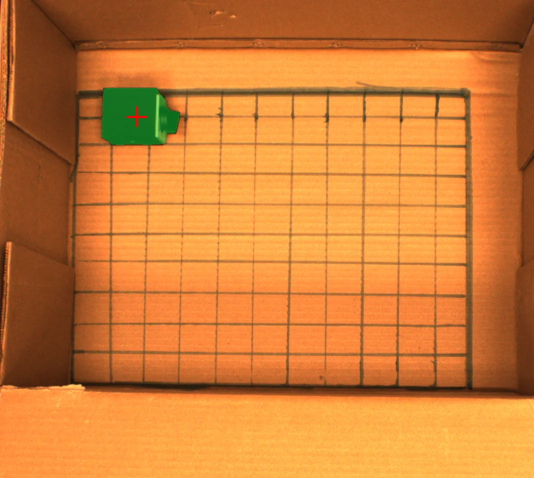

{}

In [27]:
# initial grid to start
index = 0
show_safe_missing_sample(index)
manual_layouts

index: 0 / 90
sample_id: 27
source_dir_name: cube-00x07y_0100--31-03-19-03-14
sample_type: grid_single
speakers: 0100
parsed x/y: 0.0, 7.0
old n_objects: 1
manual annotation: None


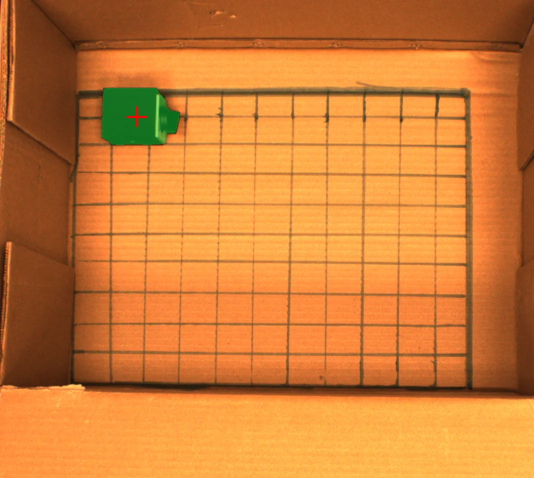

{}

In [ ]:
annotate_safe_missing_sample(27, 1, 'cube on the grid')
index += 1
show_safe_missing_sample(index)
manual_layouts

In [31]:

pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 240)

In [44]:
safe_missing_analysis_df[['sample_id', 'source_dir_name', 'sample_type', 'sample_family', 'n_objects_parsed']][75:85]

,sample_id,source_dir_name,sample_type,sample_family,n_objects_parsed
116,531,cube-8x11y_0100--31-03-20-41-16,grid_single,grid_single_in_distribution,1
117,532,cube-8x11y_1000--31-03-20-41-14,grid_single,grid_single_in_distribution,1
118,533,cube-9x11y_0001--31-03-20-41-48,grid_single,grid_single_in_distribution,1
119,534,cube-9x11y_0010--31-03-20-41-46,grid_single,grid_single_in_distribution,1
120,535,cube-9x11y_0100--31-03-20-41-44,grid_single,grid_single_in_distribution,1
121,536,cube-9x11y_1000--31-03-20-41-42,grid_single,grid_single_in_distribution,1
122,537,cube-L-01_0001--31-03-21-18-06,shape_l,ood_shape_l,1
123,538,cube-L-01_0010--31-03-21-18-05,shape_l,ood_shape_l,1
124,539,cube-L-01_0100--31-03-21-18-03,shape_l,ood_shape_l,1
125,540,cube-L-01_1000--31-03-21-18-01,shape_l,ood_shape_l,1


In [49]:
df = pd.read_csv("../recovery_inventory_from_failures.csv")
df['sample_id'].tail(10)

192    607
193    608
194    609
195    610
196    611
197    612
198    613
199    614
200    615
201    616
Name: sample_id, dtype: int64